In [3]:
## import the necessary libraries

import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
%matplotlib inline 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns


In [4]:
## Load the dataset

sales_data = pd.read_csv("../dataset/sales.csv")

display(sales_data.head())

display(sales_data.shape)

display(sales_data.dtypes)

sales_data["state_holiday"].value_counts

sales_data["open"].value_counts

sales_data["school_holiday"].value_counts


## Check for any missing data
print("Missing values in the dataset:")
display(sales_data.isna().sum())

sales_data.describe()




,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


(640840, 10)

Unnamed: 0             int64
store_ID               int64
day_of_week            int64
date                     str
nb_customers_on_day    int64
open                   int64
promotion              int64
state_holiday            str
school_holiday         int64
sales                  int64
dtype: object

Missing values in the dataset:


Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [5]:
def preprocess_data(df, drop_col, target_col):
    """ Drops one column and converts values in target_col: '0', 'A', 'B', 'C' -> 1.0 """
    df = df.copy()

    # Drop the column
    df = df.drop(columns=[drop_col])

    # # Replace values with 1.0
    df[target_col] = df[target_col].replace({ '0': 0.0, 'a': 1.0, 'b': 1.0, 'c': 1.0 }).astype(int)

    return df


In [6]:
## Split the data with train/validation/test in 70/15/15

# Drop the not-required columns
sales_data = preprocess_data(sales_data, "date", "state_holiday")
sales_data = preprocess_data(sales_data, "Unnamed: 0", "state_holiday")

# Picking the rows only when the shop is open
sales_data = sales_data[sales_data["open"]==1]
sales_data = preprocess_data(sales_data, "open", "state_holiday")

# Split the dataset to train and target sets
sales_x = sales_data.drop(columns="sales")
sales_y = sales_data["sales"]

# Perform split 70/30
X_train, dummy_x, y_train, dummy_y = train_test_split(sales_x, sales_y, test_size=0.3, random_state=42)

# Perform split 70/15/15
X_val, X_test, y_val, y_test = train_test_split(dummy_x, dummy_y, test_size=0.5, random_state=42)

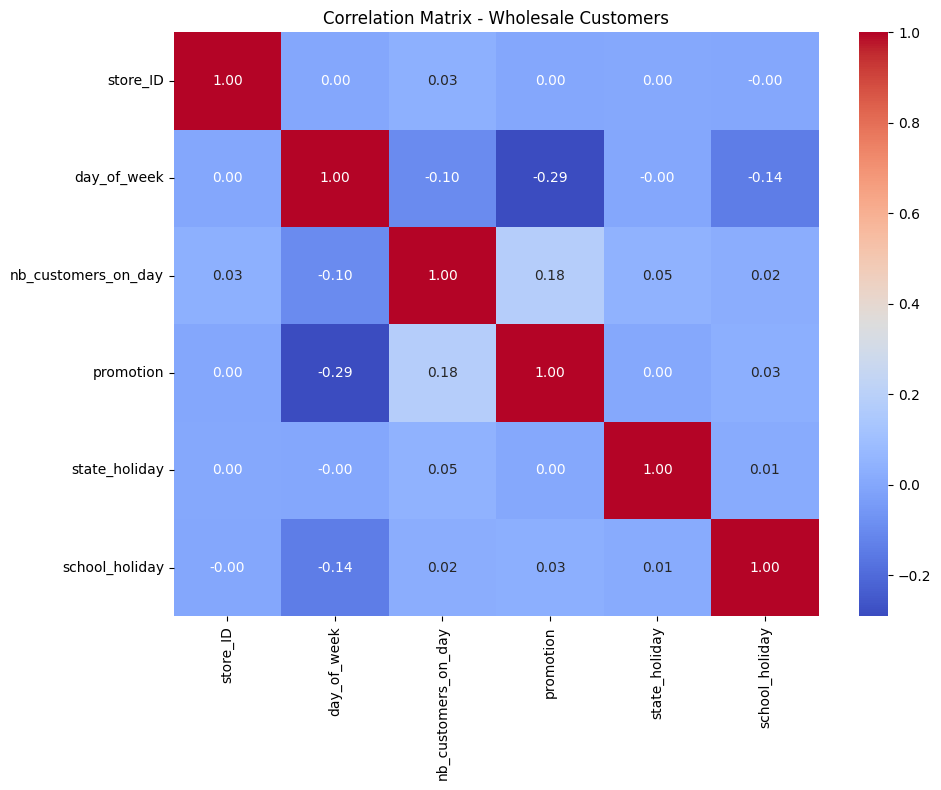

In [7]:
## Correlation matrix for understanding the feature dependency
correlation_matrix = X_train.corr()

# Visualzing correlation with a heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - Wholesale Customers')
plt.tight_layout()
plt.show()


In [8]:
# Establish a base model
from sklearn import linear_model

# Considering Liner regression as a base model
model = linear_model.LinearRegression()

# Train the linear regression model
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ -0.17, -71.15, 6.05, 1330.03,-1754.29, 58.42]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['store_ID','day_of_week','nb_customers_on_day','promotion', 'state_holiday','school_holiday']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2083
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


In [9]:
from sklearn.metrics import r2_score, mean_absolute_error

# Evaluate the Linear regression model
pred = model.predict(X_train)

print("MAE with base Linear regression model:", mean_absolute_error(y_train, pred))
print("R²  with base Linear regression model:", r2_score(y_train, pred))



MAE with base Linear regression model: 1154.5830973335783
R²  with base Linear regression model: 0.729833774093334


In [10]:
## Check the model on validation set

pred_val = model.predict(X_val)

print("MAE on validation set:", mean_absolute_error(y_val, pred_val))
print("R² on validation set:", r2_score(y_val, pred_val))

MAE on validation set: 1156.5294715694
R² on validation set: 0.729073763834869


In [11]:
# Test with polynomial Linear Regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Polynomial Linear Regression
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear", linear_model.LinearRegression())
])
# Train
poly_model.fit(X_train, y_train)

# Predict
y_pred = poly_model.predict(X_train)

# Evaluation
print("MAE:", mean_absolute_error(y_train, y_pred))
print("R² :", r2_score(y_train, y_pred))



MAE: 1105.434235061243
R² : 0.7584512749926864


In [12]:
## Check the ploynomial model on validation set

pred_val = poly_model.predict(X_val)

print("MAE on validation set:", mean_absolute_error(y_val, pred_val))
print("R² on validation set:", r2_score(y_val, pred_val))

MAE on validation set: 1104.1062233225605
R² on validation set: 0.7588900154155112


In [13]:
# Polynomial Linear Regression with degree 3
poly_model3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear", linear_model.LinearRegression())
])
# Train
poly_model3.fit(X_train, y_train)

# Predict
y_pred = poly_model3.predict(X_train)

# Evaluation
print("MAE:", mean_absolute_error(y_train, y_pred))
print("R² :", r2_score(y_train, y_pred))

MAE: 1093.030010982839
R² : 0.7659708415488523


In [27]:
## Check the ploynomial model on validation set

pred_val3 = poly_model3.predict(X_val)

print("MAE on validation set:", mean_absolute_error(y_val, pred_val3))
print("R² on validation set:", r2_score(y_val, pred_val3))

MAE on validation set: 1091.4675515964182
R² on validation set: 0.7664089047573823


In [28]:
# Check a different model : KNN

from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor

# KNN Pipeline
knn_model = Pipeline([ ("scaler", StandardScaler()), ("knn", KNeighborsRegressor( n_neighbors=3, weights="distance" )) ])

# Train
knn_model.fit(X_train, y_train)

# Predict
y_pred = knn_model.predict(X_train) 

# Evaluate
print("MAE:", mean_absolute_error(y_train, y_pred))
print("R² :", r2_score(y_train, y_pred))



MAE: 21.28328289622666
R² : 0.9992278776245417


In [29]:
## Check the KNN model on validation set

pred_val = knn_model.predict(X_val)

print("MAE on validation set with KNN:", mean_absolute_error(y_val, pred_val))
print("R² on validation set with KNN:", r2_score(y_val, pred_val))

MAE on validation set with KNN: 893.1285600815484
R² on validation set with KNN: 0.8072623033194061


In [30]:
# test the model with XGBoost

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"      # Faster on large datasets
)
preprocess_data
param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

from sklearn.model_selection import RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,                    # Try 20 random combinations
    scoring="r2",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
search.fit(X_train, y_train)
print("Best R2:", search.best_score_)
print("Best Parameters:")
print(search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best R2: 0.8864869674046835
Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [31]:
## Check the XGBoost model on validation set

pred_val = model.predict(X_val)

print("MAE on validation set with XGBoost:", mean_absolute_error(y_val, pred_val))
print("R² on validation set with XGBoost:", r2_score(y_val, pred_val))





MAE on validation set with XGBoost: 1156.5294715694
R² on validation set with XGBoost: 0.729073763834869


In [32]:
## Check the XGBoost model on test set

pred_test = model.predict(X_test)

print("MAE on test set with XGBoost:", mean_absolute_error(y_test, pred_test))
print("R² on test set with XGBoost:", r2_score(y_test, pred_test))

MAE on test set with XGBoost: 1150.4606906972094
R² on test set with XGBoost: 0.729092043524727


In [33]:

## Validation with the best XGBoost model
 
best_model = search.best_estimator_
y_pred = best_model.predict(X_val)
r2 = r2_score(y_val, y_pred)
print(f"Test R²: {r2:.4f}")

Test R²: 0.8863


In [34]:
## Test with the best model till now

y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Test R²: {r2:.4f}")

Test R²: 0.8825


In [1]:
inference_data = pd.read_csv("../dataset/inference.csv")

clean_inference_data = preprocess_data(inference_data, "date", "state_holiday")
clean_inference_data = preprocess_data(clean_inference_data, "Unnamed: 0", "state_holiday")
clean_inference_data = clean_inference_data[clean_inference_data["open"] == 1]
clean_inference_data = preprocess_data(clean_inference_data, "open", "state_holiday")
clean_inference_data = preprocess_data(clean_inference_data, "index", "state_holiday")
clean_inference_data = preprocess_data(clean_inference_data, "sales", "state_holiday")


NameError: name 'pd' is not defined

In [65]:
y = best_model.predict(clean_inference_data)

inference_data['sales'] = 0  # default for closed rows

open_mask = inference_data['open'] == 1

# Fail loudly on a mismatch instead of a cryptic crash or a silent wrong-row assignment
assert open_mask.sum() == len(y), (
    f"Mismatch: {open_mask.sum()} open rows but {len(y)} predictions"
)

inference_data.loc[open_mask, 'sales'] = np.round(y)

display(inference_data.head())




,Unnamed: 0,index,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,0,272371,415,7,01/03/2015,0,0,0,0,0,0
1,1,558468,27,7,29/12/2013,0,0,0,0,0,0
2,2,76950,404,3,19/03/2014,657,1,1,0,0,6611
3,3,77556,683,2,29/01/2013,862,1,0,0,0,6943
4,4,456344,920,3,19/03/2014,591,1,1,0,0,5937


In [66]:
inference_data.to_csv("../dataset/inference.csv")